In [1]:
# Get the size of politifact dataset

import pandas as pd


politifact_data = pd.read_csv('../datasets/politifact.csv')
print("Number of entries in the PolitiFact dataset:", len(politifact_data))

Number of entries in the PolitiFact dataset: 26342


In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv('../datasets/politifact.csv')

# Filter out rows that contain 'PolitiFact en Español' in the 'tags' column
cleaned_data = data[~data['tags'].str.contains('PolitiFact en Español', na=False)]

# Filter out rows whose verdict is 'np-flip','half-flip','full-flop'
cleaned_data = cleaned_data[~cleaned_data['verdict'].isin(['no-flip', 'half-flip', 'full-flop'])]

# Save the cleaned dataset to a new CSV file    
cleaned_data.to_csv('../datasets/politifact-english.csv', index=False)

In [3]:
# Get the size of politifact dataset after cleaning

import pandas as pd


politifact_data = pd.read_csv('../datasets/politifact-english.csv')
print("Number of entries in the PolitiFact dataset after cleaning:", len(politifact_data))

Number of entries in the PolitiFact dataset after cleaning: 25669


In [4]:
# Count statements per tag

import pandas as pd

# Read the dataset
politifact_data = pd.read_csv('../datasets/politifact-english.csv')

# Dictionary to store tag counts
tag_counts = {}

# Iterate through each row
for index, row in politifact_data.iterrows():
    tags = row['tags']
    
    # Skip if tags are empty or NaN
    if pd.isna(tags) or tags == '':
        continue
    
    # Split tags by semicolon and strip whitespace
    tag_list = [tag.strip() for tag in tags.split(';')]
    
    # Count each tag
    for tag in tag_list:
        if tag:  # Make sure tag is not empty
            tag_counts[tag] = tag_counts.get(tag, 0) + 1

# Convert to DataFrame and sort by count
tag_df = pd.DataFrame(list(tag_counts.items()), columns=['Tag', 'Count'])
tag_df = tag_df.sort_values('Count', ascending=False)

print(f"Total unique tags: {len(tag_df)}")
print(f"\nTop 20 most common tags:\n")
print(tag_df.head(20).to_string(index=False))

# Optional: Show full list
print(f"\n\nAll tags sorted by frequency:")
print(tag_df.to_string(index=False))

Total unique tags: 186

Top 20 most common tags:

                 Tag  Count
            National   6607
Facebook Fact-checks   5904
           Elections   2148
         Health Care   2133
           Wisconsin   2032
             Economy   1969
             Florida   1873
               Texas   1737
               Taxes   1708
         Coronavirus   1562
         Immigration   1417
           Education   1377
          PunditFact   1333
       Public Health   1290
               Crime   1189
      Federal Budget   1182
                Jobs   1181
        State Budget   1049
             Georgia   1027
 Candidate Biography   1023


All tags sorted by frequency:
                                Tag  Count
                           National   6607
               Facebook Fact-checks   5904
                          Elections   2148
                        Health Care   2133
                          Wisconsin   2032
                            Economy   1969
                            F

In [5]:
# Filter out rows with video/image statements (optimized)

import pandas as pd

# Read the dataset
df = pd.read_csv('../datasets/politifact-english.csv')
print(f"Original dataset size: {len(df)}")

# Simplified filter pattern (non-capturing group to avoid warning)
filter_pattern = r'\b(?:video|image|photo)s?\b'

# Create masks efficiently
mask_statement = ~df['statement'].str.contains(filter_pattern, case=False, na=False, regex=True)
# Use .ne() which is faster
mask_originator = df['statement_originator'].ne('Viral image')

# Combine both masks
mask = mask_statement & mask_originator

# Apply the filter
filtered_df = df[mask]

print(f"Filtered dataset size: {len(filtered_df)}")
print(f"Rows removed: {len(df) - len(filtered_df)}")

# Save to new CSV
filtered_df.to_csv('../datasets/politifact-english-no-media.csv', index=False)
print("\nFiltered dataset saved to 'datasets/politifact-english-no-media.csv'")

Original dataset size: 25669
Filtered dataset size: 23401
Rows removed: 2268

Filtered dataset saved to 'datasets/politifact-english-no-media.csv'


In [6]:
# Count statements per tag

import pandas as pd

# Read the dataset
politifact_data = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Dictionary to store tag counts
tag_counts = {}

# Iterate through each row
for index, row in politifact_data.iterrows():
    tags = row['tags']
    
    # Skip if tags are empty or NaN
    if pd.isna(tags) or tags == '':
        continue
    
    # Split tags by semicolon and strip whitespace
    tag_list = [tag.strip() for tag in tags.split(';')]
    
    # Count each tag
    for tag in tag_list:
        if tag:  # Make sure tag is not empty
            tag_counts[tag] = tag_counts.get(tag, 0) + 1

# Convert to DataFrame and sort by count
tag_df = pd.DataFrame(list(tag_counts.items()), columns=['Tag', 'Count'])
tag_df = tag_df.sort_values('Count', ascending=False)

print(f"Total unique tags: {len(tag_df)}")
print(f"\nTop 20 most common tags:\n")
print(tag_df.head(20).to_string(index=False))

# Optional: Show full list
print(f"\n\nAll tags sorted by frequency:")
print(tag_df.to_string(index=False))

Total unique tags: 185

Top 20 most common tags:

                 Tag  Count
            National   6463
Facebook Fact-checks   3938
         Health Care   2108
           Wisconsin   2007
             Economy   1955
           Elections   1954
             Florida   1821
               Texas   1700
               Taxes   1696
         Immigration   1366
           Education   1352
         Coronavirus   1336
          PunditFact   1297
       Public Health   1223
                Jobs   1180
      Federal Budget   1176
               Crime   1100
        State Budget   1047
             Georgia    994
 Candidate Biography    979


All tags sorted by frequency:
                                Tag  Count
                           National   6463
               Facebook Fact-checks   3938
                        Health Care   2108
                          Wisconsin   2007
                            Economy   1955
                          Elections   1954
                            F

Total statements with 'Health Care' tag: 2108


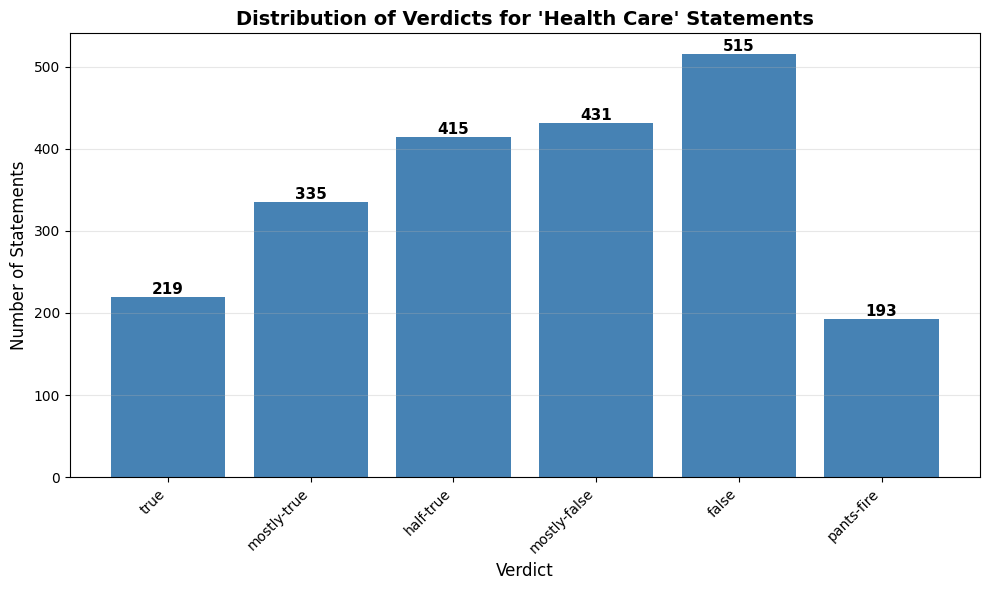


Verdict distribution:
verdict
true            219
mostly-true     335
half-true       415
mostly-false    431
false           515
pants-fire      193
Name: count, dtype: int64


In [7]:
# Plot verdicts for statements with 'Health Care' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Health Care' in tags
healthcare_df = df[df['tags'].str.contains('Health Care', case=False, na=False)]

print(f"Total statements with 'Health Care' tag: {len(healthcare_df)}")

# Count verdicts
verdict_counts = healthcare_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Health Care' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Elections' tag: 2004


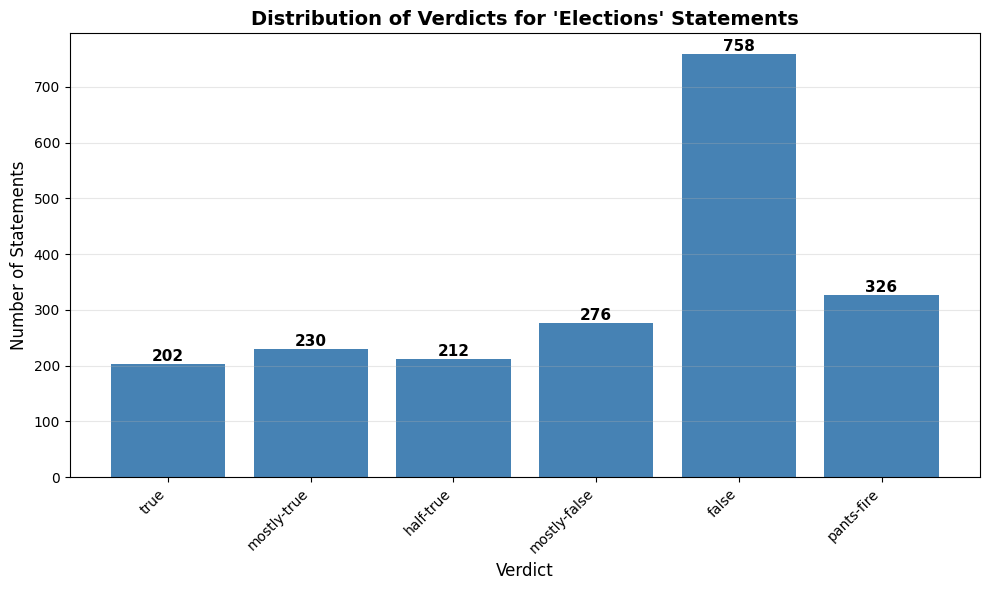


Verdict distribution:
verdict
true            202
mostly-true     230
half-true       212
mostly-false    276
false           758
pants-fire      326
Name: count, dtype: int64


In [8]:
# Plot verdicts for statements with 'Elections' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Elections' in tags
elections_df = df[df['tags'].str.contains('Elections', case=False, na=False)]

print(f"Total statements with 'Elections' tag: {len(elections_df)}")

# Count verdicts
verdict_counts = elections_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Elections' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Economy' tag: 1955


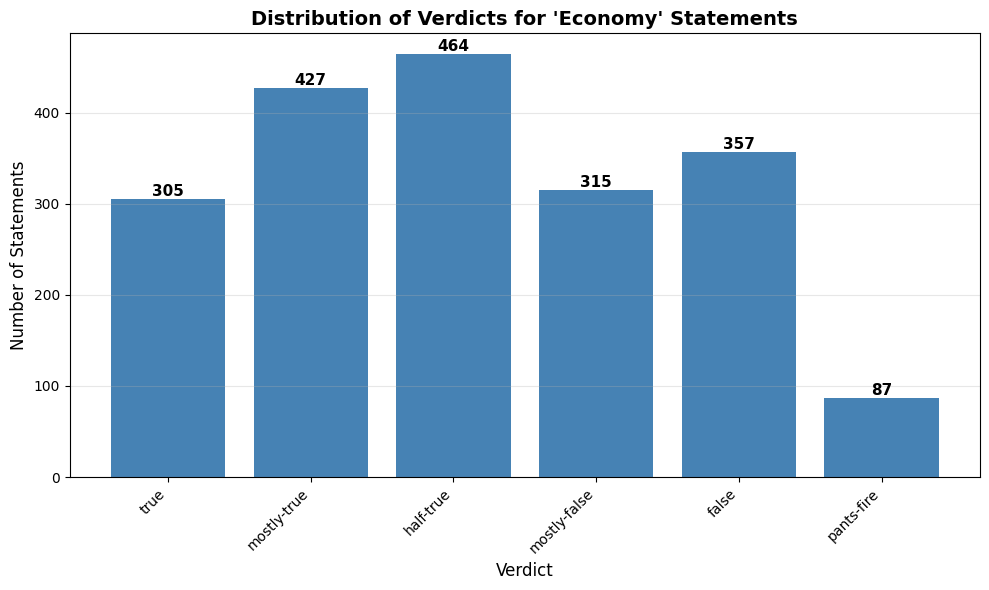


Verdict distribution:
verdict
true            305
mostly-true     427
half-true       464
mostly-false    315
false           357
pants-fire       87
Name: count, dtype: int64


In [9]:
# Plot verdicts for statements with 'Economy' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Economy' in tags
economy_df = df[df['tags'].str.contains('Economy', case=False, na=False)]

print(f"Total statements with 'Economy' tag: {len(economy_df)}")

# Count verdicts
verdict_counts = economy_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Economy' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Taxes' tag: 1696


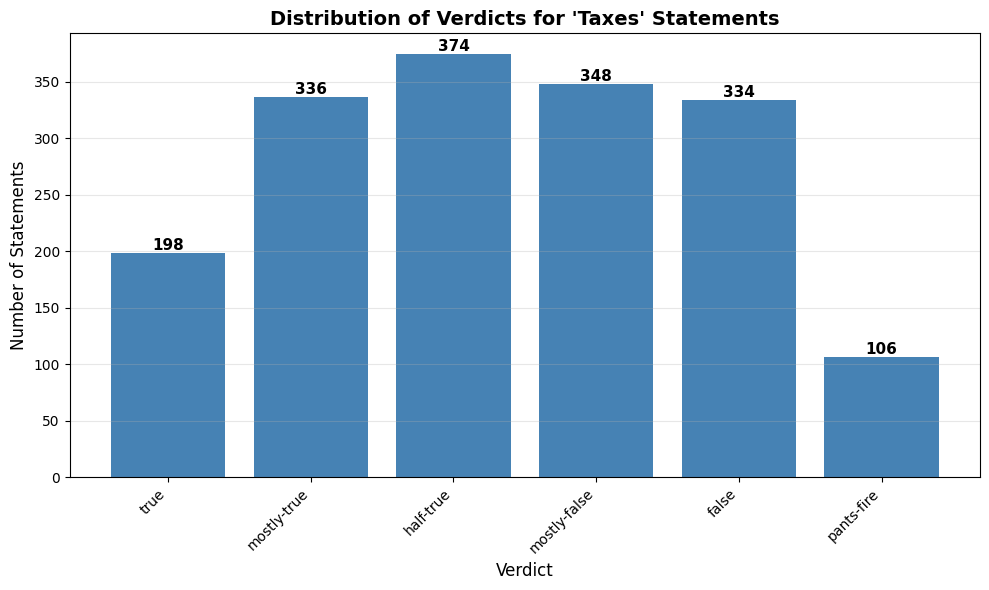


Verdict distribution:
verdict
true            198
mostly-true     336
half-true       374
mostly-false    348
false           334
pants-fire      106
Name: count, dtype: int64


In [10]:
# Plot verdicts for statements with 'Taxes' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Taxes' in tags
taxes_df = df[df['tags'].str.contains('Taxes', case=False, na=False)]

print(f"Total statements with 'Taxes' tag: {len(taxes_df)}")

# Count verdicts
verdict_counts = taxes_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Taxes' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Immigration' tag: 1366


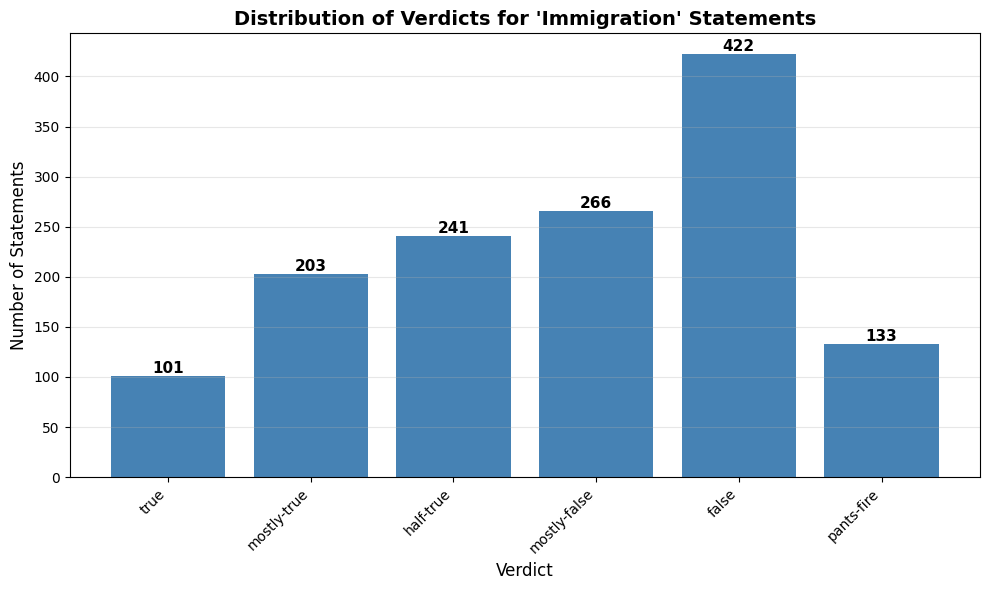


Verdict distribution:
verdict
true            101
mostly-true     203
half-true       241
mostly-false    266
false           422
pants-fire      133
Name: count, dtype: int64


In [11]:
# Plot verdicts for statements with 'Immigration' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Immigration' in tags
immigration_df = df[df['tags'].str.contains('Immigration', case=False, na=False)]

print(f"Total statements with 'Immigration' tag: {len(immigration_df)}")

# Count verdicts
verdict_counts = immigration_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Immigration' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Education' tag: 1352


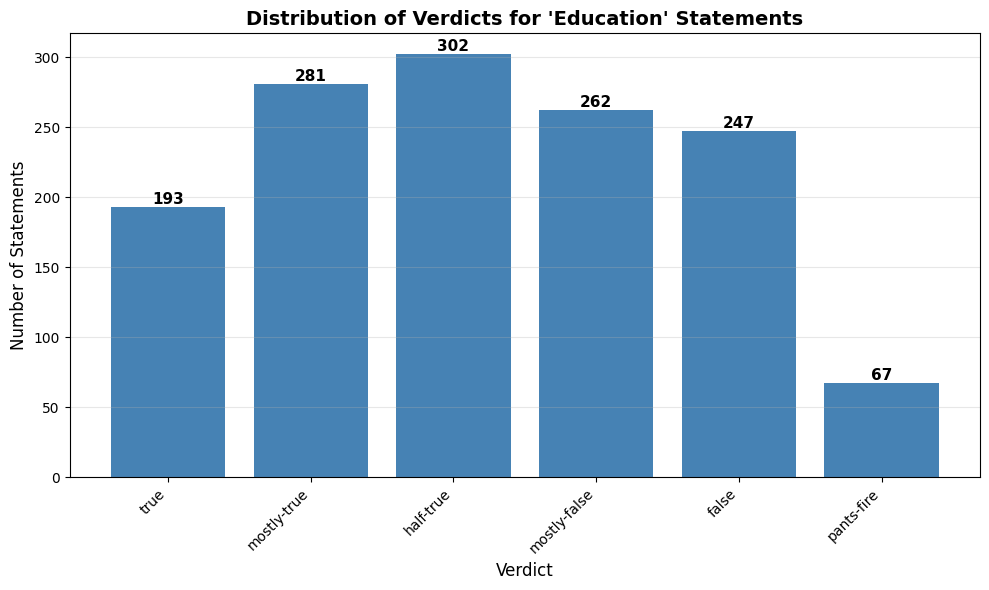


Verdict distribution:
verdict
true            193
mostly-true     281
half-true       302
mostly-false    262
false           247
pants-fire       67
Name: count, dtype: int64


In [12]:
# Plot verdicts for statements with 'Education' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Education' in tags
education_df = df[df['tags'].str.contains('Education', case=False, na=False)]

print(f"Total statements with 'Education' tag: {len(education_df)}")

# Count verdicts
verdict_counts = education_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Education' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Crime' tag: 1100


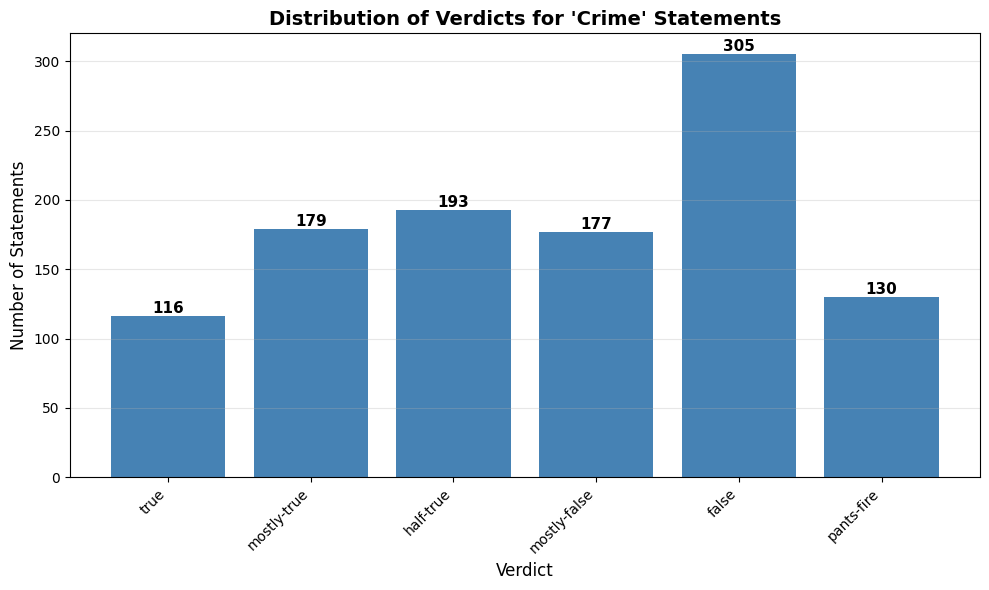


Verdict distribution:
verdict
true            116
mostly-true     179
half-true       193
mostly-false    177
false           305
pants-fire      130
Name: count, dtype: int64


In [13]:
# Plot verdicts for statements with 'Crime' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Crime' in tags
crime_df = df[df['tags'].str.contains('Crime', case=False, na=False)]

print(f"Total statements with 'Crime' tag: {len(crime_df)}")

# Count verdicts
verdict_counts = crime_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Crime' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

Total statements with 'Jobs' tag: 1180


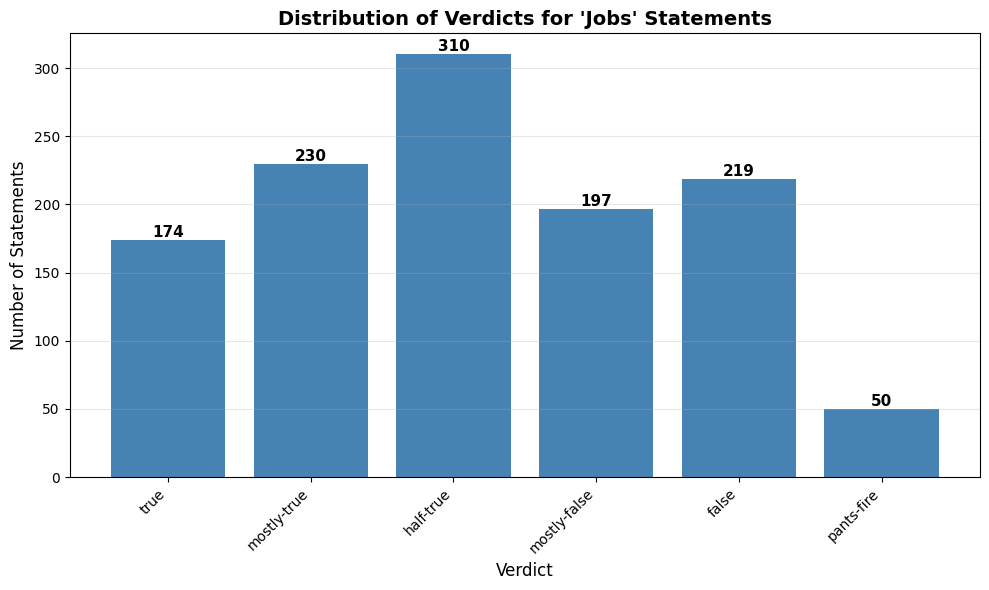


Verdict distribution:
verdict
true            174
mostly-true     230
half-true       310
mostly-false    197
false           219
pants-fire       50
Name: count, dtype: int64


In [14]:
# Plot verdicts for statements with 'Jobs' tag

import pandas as pd
import matplotlib.pyplot as plt

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')

# Filter rows that contain 'Jobs' in tags
jobs_df = df[df['tags'].str.contains('Jobs', case=False, na=False)]

print(f"Total statements with 'Jobs' tag: {len(jobs_df)}")

# Count verdicts
verdict_counts = jobs_df['verdict'].value_counts()

# Define the desired order
verdict_order = ['true', 'mostly-true', 'half-true', 'mostly-false', 'false', 'pants-fire']

# Reindex to the specified order, filling missing values with 0
verdict_counts = verdict_counts.reindex(verdict_order, fill_value=0)

# Create bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(range(len(verdict_counts)), verdict_counts.values, color='steelblue')

# Add value labels on top of each bar
for i, (bar, value) in enumerate(zip(bars, verdict_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(value)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title("Distribution of Verdicts for 'Jobs' Statements", fontsize=14, fontweight='bold')
ax.set_xlabel('Verdict', fontsize=12)
ax.set_ylabel('Number of Statements', fontsize=12)
ax.set_xticks(range(len(verdict_counts)))
ax.set_xticklabels(verdict_counts.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print the counts
print("\nVerdict distribution:")
print(verdict_counts)

In [15]:
# Create CSV files for multiple tags

import pandas as pd

# Read the dataset
df = pd.read_csv('../datasets/politifact-english-no-media.csv')
print(f"Original dataset size: {len(df)}\n")

# Define tags to filter
tags_to_filter = ['Health Care', 'Elections', 'Economy', 'Taxes', 'Immigration', 'Education', 'Crime', 'Jobs']

# Process each tag
for tag in tags_to_filter:
    # Filter rows that contain the tag
    filtered_df = df[df['tags'].str.contains(tag, case=False, na=False)]
    
    # Create filename (lowercase, replace spaces with hyphens)
    filename = f"../datasets/calibrated/politifact-{tag.lower().replace(' ', '-')}.csv"
    
    # Save to CSV
    filtered_df.to_csv(filename, index=False)
    
    print(f"{tag}: {len(filtered_df)} rows -> {filename}")

print("\nAll datasets created successfully!")

Original dataset size: 23401

Health Care: 2108 rows -> ../datasets/calibrated/politifact-health-care.csv
Elections: 2004 rows -> ../datasets/calibrated/politifact-elections.csv
Economy: 1955 rows -> ../datasets/calibrated/politifact-economy.csv
Taxes: 1696 rows -> ../datasets/calibrated/politifact-taxes.csv
Immigration: 1366 rows -> ../datasets/calibrated/politifact-immigration.csv
Education: 1352 rows -> ../datasets/calibrated/politifact-education.csv
Crime: 1100 rows -> ../datasets/calibrated/politifact-crime.csv
Jobs: 1180 rows -> ../datasets/calibrated/politifact-jobs.csv

All datasets created successfully!


In [16]:
# Convert CSV to JSON

import pandas as pd
import json

# Input and output file paths
csv_file = '../datasets/politifact-english-no-media.csv'
json_file = '../datasets/politifact-english-no-media.json'

# Read CSV
df = pd.read_csv(csv_file)
print(f"Read {len(df)} rows from {csv_file}")

# Convert to JSON (records format - array of objects)
df.to_json(json_file, orient='records', indent=2)

print(f"Converted to JSON: {json_file}")
print(f"File size: {len(df)} records")

datasets = ['crime', 'economy', 'education', 'elections', 'health-care', 'immigration', 'jobs', 'taxes']

for i in datasets:
    csv_file = f'../datasets/calibrated/politifact-{i}.csv'
    json_file = f'../datasets/calibrated/json/politifact-{i}.json'
    
    df = pd.read_csv(csv_file)
    print(f"Read {len(df)} rows from {csv_file}")

    # Convert to JSON (records format - array of objects)
    df.to_json(json_file, orient='records', indent=2)

    print(f"Converted to JSON: {json_file}")
    print(f"File size: {len(df)} records")


Read 23401 rows from ../datasets/politifact-english-no-media.csv
Converted to JSON: ../datasets/politifact-english-no-media.json
File size: 23401 records
Read 1100 rows from ../datasets/calibrated/politifact-crime.csv
Converted to JSON: ../datasets/calibrated/json/politifact-crime.json
File size: 1100 records
Read 1955 rows from ../datasets/calibrated/politifact-economy.csv
Converted to JSON: ../datasets/calibrated/json/politifact-economy.json
File size: 1955 records
Read 1352 rows from ../datasets/calibrated/politifact-education.csv
Converted to JSON: ../datasets/calibrated/json/politifact-education.json
File size: 1352 records
Read 2004 rows from ../datasets/calibrated/politifact-elections.csv
Converted to JSON: ../datasets/calibrated/json/politifact-elections.json
File size: 2004 records
Read 2108 rows from ../datasets/calibrated/politifact-health-care.csv
Converted to JSON: ../datasets/calibrated/json/politifact-health-care.json
File size: 2108 records
Read 1366 rows from ../datase